In [353]:
# Importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense,Dropout, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 
from tensorflow.keras.regularizers import l2
from gensim.models import Word2Vec
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score,roc_auc_score)
import warnings
warnings.filterwarnings("ignore")


In [354]:
# Loading the dataset
df_original = pd.read_csv("D:/Python programming/Projects/Sentiment Analysis- US Airline Reviews/dataset/tweets.csv")
df = df_original[["text", "airline_sentiment"]]

In [355]:
df.sample(5)

,text,airline_sentiment
1432,@united quick (serious) question - any resources/ratings showing the quality of service is better than 8th place? http://t.co/deWIthPeW2,negative
6368,@SouthwestAir What are your services? What promotion you have at the moment? #ModeloDeNegocio #innovation #innovacion #BusinessModel,neutral
8434,@JetBlue Marks 15th Year With 'Bluemanity' Plane Design - http://t.co/E5NaxBUe4s http://t.co/KlxivnbCYh,neutral
12913,@AmericanAir instead they yelled at him and told him to call a number that will not pick up due to call volume,negative
6102,"@SouthwestAir, I really appreciate you all's #BHM commercial that aired today during @BET's #BookofNegroes",positive


## Text Preprocessing

In [356]:
# Checking for null values
df.isnull().sum()

text                 0
airline_sentiment    0
dtype: int64

In [357]:
# Checking duplicates
print(f"Number of duplicates {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates has been removed")
print(f"Number of duplicates {df.duplicated().sum()}")

Number of duplicates 188
Duplicates has been removed
Number of duplicates 0


#### Text Cleaning

In [358]:
# ------------------------------------------------------------
# Text preprocessing function
# ------------------------------------------------------------

negative_contractions = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "won't": "will not", "wouldn't": "would not",
    "can't": "cannot", "couldn't": "could not", "shouldn't": "should not",
    "mustn't": "must not", "mightn't": "might not", "needn't": "need not"}


def preprocess_text(text):
    text = text.lower()

    # Expand negative contractions to preserve explicit negation.
    for contraction, expansion in negative_contractions.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)

    # Remove email addresses because they mainly contain contact information.
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove URLs because they generally provide little sentiment information.
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove HTML entities such as &amp;, &quot; and &nbsp;.
    text = re.sub(r'&[a-zA-Z0-9#]+;', ' ', text)

    # Remove only the "#" symbol while keeping the hashtag text.
    text = re.sub(r'#', '', text)

    # Remove emojis because we decided to keep the initial
    emoji_pattern = re.compile(
        "[" 
        "\U0001F300-\U0001F5FF"
        "\U0001F600-\U0001F64F"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FAFF"
        "\U00002600-\U000026FF"
        "\U00002700-\U000027BF"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub(' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation and special characters.
    text = re.sub(r'[^\w\s]', ' ', text)

    # Normalize repeated characters such as "goooood" → "good" and "soooo" → "soo".
    text = re.sub(r'([a-z])\1{2,}', r'\1\1', text)

    # Remove extra whitespace created during preprocessing.
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [359]:
# Text cleaning
df["clean_text"] = df["text"].fillna("").apply(preprocess_text)

pd.set_option('display.max_colwidth', None)

comparison = df[["text", "clean_text"]].sample(5, random_state=41)

display(comparison)

,text,clean_text
8616,@JetBlue The Magic eight ball has never steered me wrong :),jetblue the magic eight ball has never steered me wrong
3479,@united Thank you! Off to LA to do something very special.,united thank you off to la to do something very special
5631,@SouthwestAir Apparently mechanics had to be flown in to fix some planes...not the most assuring sign,southwestair apparently mechanics had to be flown in to fix some planes not the most assuring sign
8959,@JetBlue sitting on the plane in JFK waiting to take off doors are open catering is stocking up we are delayed but they couldn't be nicer,jetblue sitting on the plane in jfk waiting to take off doors are open catering is stocking up we are delayed but they could not be nicer
7120,Do less please @JetBlue,do less please jetblue


#### Target Variable Encoding

In [360]:
# Encoding the target variable
le = LabelEncoder()
df["airline_sentiment_encoded"] = le.fit_transform(df["airline_sentiment"])
print(df.airline_sentiment_encoded.unique())

[1 2 0]


In [361]:
print("Encoded Labels:")
print(f"0 -> Negative, 1 -> Netral, 2 -> Positive")

Encoded Labels:
0 -> Negative, 1 -> Netral, 2 -> Positive


#### Train-Test-Split

In [362]:
# Train test split
input = "text"
target = "airline_sentiment_encoded"
x = df["clean_text"]
y = df[target]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=41)

#### Tokenization

In [363]:
tokenizer = Tokenizer(oov_token="<OOV>") # Creating tokenizer object
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)
print(f"Vocabulary Size: {len(tokenizer.word_index) + 1}")


Vocabulary Size: 10644


#### OOV Rate

In [364]:
def oov_rate(text_seq):
    seq = text_seq
    oov_index = tokenizer.word_index["<OOV>"]
    total_token = sum([len(sequence) for sequence in seq])
    oov_tokens = sum([sequence.count(oov_index) for sequence in seq])
    oov_rate = (oov_tokens/total_token)*100
    print(f"OOV rate: {oov_rate:.2f}%")

In [365]:
oov_rate(x_test_seq)

OOV rate: 2.71%


#### Padding

In [366]:
max_lenght = 36
x_train_pad = pad_sequences(x_train_seq, maxlen=max_lenght, padding="post")
x_test_pad = pad_sequences(x_test_seq, maxlen=max_lenght, padding="post" )

In [367]:
x

0                                                                                                                     virginamerica what dhepburn said
1                                                                                  virginamerica plus you ve added commercials to the experience tacky
2                                                                                  virginamerica i did not today must mean i need to take another trip
3                                 virginamerica it s really aggressive to blast obnoxious entertainment in your guests faces they have little recourse
4                                                                                               virginamerica and it s a really big bad thing about it
                                                                             ...                                                                      
14635                                                                                    ameri

#### Word2Vec Embedding

In [368]:
sentences = x_train.apply(str.split).tolist()

w2v = Word2Vec(sentences=sentences,vector_size=100,window=5,min_count=1,workers=4,sg=1,seed=42)
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, 100))
for word, idx in tokenizer.word_index.items():
    if word in w2v.wv:
        embedding_matrix[idx] = w2v.wv[word]

print(embedding_matrix.shape)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(10644, 100)


### **BiLSTM**

In [369]:
x_train_model, x_val, y_train_model, y_val = train_test_split(x_train_pad, y_train, test_size=0.20, random_state=42, stratify=y_train)

In [370]:
model = Sequential()
model.add(Embedding(input_dim=embedding_matrix.shape[0],output_dim=embedding_matrix.shape[1],weights=[embedding_matrix],
                    trainable=False, mask_zero=True))

model.add(SpatialDropout1D(0.2))
model.add(Bidirectional(LSTM(64, dropout=0.2, return_sequences=False)))
model.add(Dense(32, activation="relu", kernel_regularizer=l2(1e-4))) 
model.add(Dropout(0.3)) 
model.add(Dense(3, activation="softmax"))
model.compile(optimizer=Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
print("--- Phase 1: Training top layers (Embedding Frozen) ---")
history_phase1 = model.fit(x_train_model, y_train_model, validation_data=(x_val, y_val),epochs=6, batch_size=36,verbose=1)

print("\n--- Phase 2: Unfreezing Embedding for Fine-Tuning ---")
model.layers[0].trainable = True
model.compile(optimizer=Adam(learning_rate=5e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

history_phase2 = model.fit(
    x_train_model,
    y_train_model,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=36,
    callbacks=callbacks,
    verbose=1
)

--- Phase 1: Training top layers (Embedding Frozen) ---
Epoch 1/6
257/257 [==============================] - 111s 238ms/step - loss: 0.7838 - accuracy: 0.6782 - val_loss: 0.6252 - val_accuracy: 0.7523
Epoch 2/6
257/257 [==============================] - 31s 122ms/step - loss: 0.6932 - accuracy: 0.7205 - val_loss: 0.6389 - val_accuracy: 0.7423
Epoch 3/6
257/257 [==============================] - 30s 118ms/step - loss: 0.6628 - accuracy: 0.7342 - val_loss: 0.5793 - val_accuracy: 0.7700
Epoch 4/6
257/257 [==============================] - 10s 37ms/step - loss: 0.6530 - accuracy: 0.7390 - val_loss: 0.5629 - val_accuracy: 0.7791
Epoch 5/6
257/257 [==============================] - 8s 31ms/step - loss: 0.6397 - accuracy: 0.7436 - val_loss: 0.5739 - val_accuracy: 0.7735
Epoch 6/6
257/257 [==============================] - 7s 25ms/step - loss: 0.6315 - accuracy: 0.7481 - val_loss: 0.5610 - val_accuracy: 0.7730

--- Phase 2: Unfreezing Embedding for Fine-Tuning ---
Epoch 1/20
257/257 [=========

#### **Evalution**

In [371]:
len(x_test_pad)

2891

In [372]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score)

y_test_prob = model.predict(x_test_pad, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average="macro")
weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")

macro_auc = roc_auc_score(y_test, y_test_prob, multi_class="ovr", average="macro")

print("TEST ACCURACY :", round(accuracy, 4))
print("MACRO F1      :", round(macro_f1, 4))
print("WEIGHTED F1   :", round(weighted_f1, 4))
print("MACRO ROC-AUC :", round(macro_auc, 4))

TEST ACCURACY : 0.7973
MACRO F1      : 0.7207
WEIGHTED F1   : 0.787
MACRO ROC-AUC : 0.9055



CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0     0.8244    0.9351    0.8763      1818
           1     0.6875    0.5204    0.5924       613
           2     0.7836    0.6217    0.6933       460

    accuracy                         0.7973      2891
   macro avg     0.7652    0.6924    0.7207      2891
weighted avg     0.7889    0.7973    0.7870      2891


CONFUSION MATRIX

[[1700   94   24]
 [ 239  319   55]
 [ 123   51  286]]


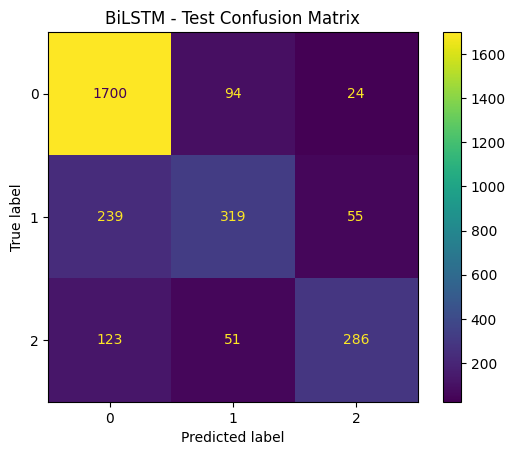

In [373]:
print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_test,y_test_pred,digits=4))

cm = confusion_matrix(y_test, y_test_pred)
print("\nCONFUSION MATRIX\n")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("BiLSTM - Test Confusion Matrix")
plt.show()

### BiLSTM — Conclusion

- The final BiLSTM model achieved **79.63% test accuracy**, demonstrating good overall sentiment classification performance.
- Class 0 was predicted strongly, achieving **93.67% recall** and **87.40% F1-score**.
- Class 1 remained the most challenging, with **50.57% recall** and **58.27% F1-score**, indicating higher confusion with other sentiment classes.
- The model achieved a **Macro-F1 of 0.7202**, showing reasonably balanced performance across the three classes.
- Overall, the BiLSTM provides a **solid deep-learning baseline**, with **Class 1 being the primary area for further improvement**.